In [11]:
from pathlib import Path
import typing
import json

import matplotlib.pyplot as plt
import networkx as nx


In [2]:
def load_best_run(experiments_path: str) -> dict:
    summary = json.loads(Path(experiments_path, "summary.json").read_text())
    return summary[0]

In [3]:
def load_predicted_clusters(experiments_path: str, run_id: str, word: str) ->dict:
    path = Path(experiments_path, "runs", run_id, "clusters", f"{word}.json")
    return json.loads(path.read_text())

In [4]:
def get_predicted_sizes(cluster_data: dict) -> dict:
    return {f"Sense {c['id']}": len(c["sentences"]) for c in cluster_data["clusters"]}

In [5]:
def get_gold_sizes(gold_list: typing.List) -> dict:
    return {f"Sense {i}": freq for i, freq in enumerate(gold_list)}

In [6]:
def plot_cluster_comparison(
    predicted_sizes: dict,
    gold_sizes: dict,
    word: str,
    save_path: str = None,
):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, sizes, title, color in zip(
        axes,
        [predicted_sizes, gold_sizes],
        [f"{word} - Predicted", f"{word} - Gold"],
        ["steelblue", "coral"],
    ):
        bars = ax.bar(
            sizes.keys(),
            sizes.values(),
            color=color,
            edgecolor="white",
            linewidth=0.8,
        )
        
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_xlabel("Sense", fontsize=11)
        ax.set_ylabel("Number of instances", fontsize=11)
        
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                str(int(bar.get_height())),
                ha="center",
                va="bottom",
                fontsize=10,
            )
            
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

In [7]:
gold_clusters = {
    "planta": [21, 9, 6, 2, 1, 1],
}
experiments_path = "./results/sc/dwug_es/llama3.3/"
best = load_best_run(experiments_path)

In [8]:
print(f"Best run: {best['run']} - Spearman: {best['spearman']:.4f}")
print(f"Params: {best['params']}")

Best run: run_003 - Spearman: 0.6432
Params: {'fill_diagonal': True, 'normalize': False, 'model_hyperparameters': {'strategy': 'cluster_qr'}}



planta
  Predicted: {'Sense 0': 33, 'Sense 1': 7}
  Gold: {'Sense 0': 21, 'Sense 1': 9, 'Sense 2': 6, 'Sense 3': 2, 'Sense 4': 1, 'Sense 5': 1}


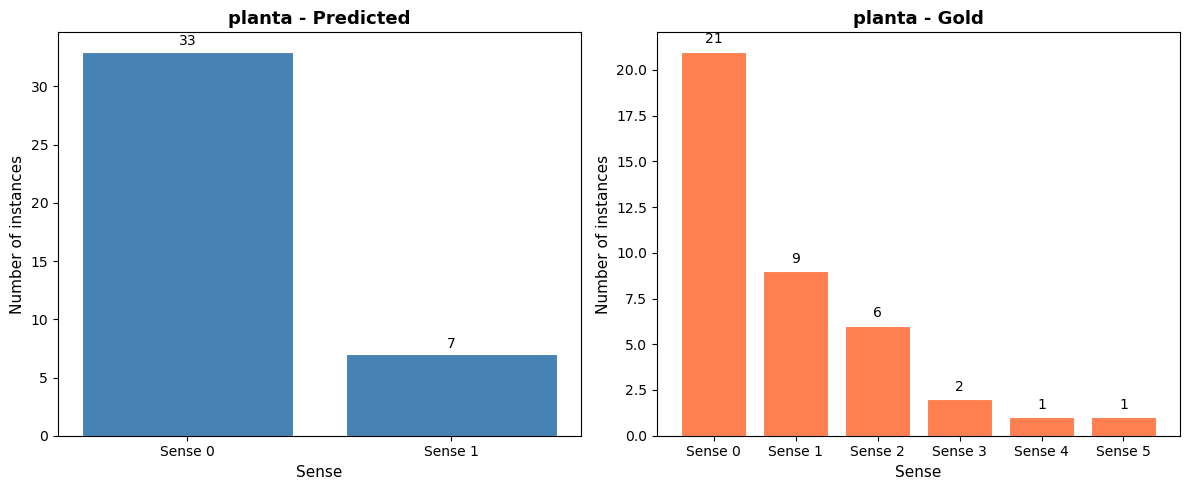

In [9]:
for word, gold in gold_clusters.items():
    cluster_data = load_predicted_clusters(experiments_path, best["run"], word)
    predicted_sizes =get_predicted_sizes(cluster_data)
    gold_sizes = get_gold_sizes(gold)
    
    print(f"\n{word}")
    print(f"  Predicted: {predicted_sizes}")
    print(f"  Gold: {gold_sizes}")
    
    plot_cluster_comparison(
        predicted_sizes,
        gold_sizes,
        word,
        save_path=f"{word}_clusters.png"
    )

In [10]:
def load_cluster_labels(experiments_path: str, run_id: str, word: str):
    path = Path(experiments_path, "runs", run_id, "clusters", f"{word}.json")
    data = json.loads(path.read_text())
    labels = {}
    for cluster in data["clusters"]:
        for sentence in cluster["sentences"]:
            labels[sentence["id"]] = cluster["id"]
            
    return labels

In [12]:
def build_graph(path_to_data: str, word: str, labels: dict) -> nx.Graph:
    df = pd.read_csv(path_to_data)
    df = df[(df["word"] == word) & (df["prediction"] != "-")]

    G = nx.Graph()

    for sentence_id, cluster_id in labels.items():
        G.add_node(sentence_id, cluster=cluster_id)

    for _, row in df.iterrows():
        weight = float(row["prediction"])
        if weight > 0:
            G.add_edge(
                row["identifier1"],
                row["identifier2"],
                weight=weight,
            )
            
    return G

In [13]:
def plot_cluster_network(G: nx.Graph, word: str, save_path: str = None):
    clusters = sorted(set(nx.get_node_attributes(G, "cluster").values()))
    colors_map = plt.cm.Set1(np.linespace(0, 0.8, len(clusters)))
    cluster_color = {c: colors_map[i] for i, c in enumerate(clusters)}

    node_colors = [cluster_color[G.nodes[n]["clusters"]] for n in G.nodes()]

    weights = [G[u][v]["weight"] for u, v in G.edges()]
    max_w = max(weights) if weight else 1
    edge_widths = [w / max_w * 2 for w in weights]
    edge_alphas = [w / max_w * 0.6 for w in weights]

    pos = nx.spring_layout(G, seed=42, weight="weight", k=0.5)

    fig, ax = plt.subplots(figsize=(10, 8))

    for (u, v), width, alpha in zip(G.edges(), edge_widths, edge_alphas):
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=[(u, v)],
            width=width,
            alpha=alpha,
            edge_color="gray",
            ax=ax,
        )

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colors,
        node_size=150,
        ax=ax,
    )

    for cluster_id, color in cluster_color.items():
        ax.scatter(
            [],
            [],
            c=[color],
            label=f"Sense {cluster_id}",
            s=100,
        )
    ax.legend(loc="best", fontsize=11)

    ax.set_title(
        f"{word} - Cluster networkx",
        fontsize=13,
        fontweight="bold",
    )
    ax.axis("off")
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
path_to_data = "../llama3.3-dwug-es.csv"

In [ ]:
for word in gold_clusters.keys():
    labels = load_cluster_labels(experiments_path, best["run"], word)
    G = build_graph(path_to_data, word, labels)
    plot_cluster_network(G, word, save_path=f"{word}_network.png")